# Combined VMD-Optuna-TCN — Plot Generation

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# ==========================================
# CONFIGURATION - MATCH run_all_vmd_optuna_tcn_experiments.py
# ==========================================
# In a .py file, __file__ works. In a notebook, __file__ is not defined,
# so we fall back to the current working directory.
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()

DATA_DIR = os.path.join(BASE_DIR, "meters", "cleaned")
ELEC_PATH = os.path.join(DATA_DIR, "electricity_cleaned.csv")

OUTPUT_DIR = os.path.join(BASE_DIR, "results_all_experiments")
METRICS_DIR = os.path.join(OUTPUT_DIR, "metrics")
PREDICTIONS_DIR = os.path.join(OUTPUT_DIR, "predictions")
STATISTICS_DIR = os.path.join(OUTPUT_DIR, "statistics")
STAT_PLOTS_DIR = os.path.join(STATISTICS_DIR, "plots")

# Notebook-generated figures will be saved here.
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots_for_paper")
TEMP_PLOT_DIR = os.path.join(PLOT_DIR, "temp_image")

MODEL_NAME = "VMD_Optuna_TCN"   # proposed model
BUILDINGS = ['Wolf', 'Bull', 'Robin', 'Fox', 'Rat', 'Eagle']
HOLDOUT_BUILDINGS = ['Wolf', 'Bull', 'Robin', 'Fox', 'Rat', 'Eagle']
HOLDOUT_START = '2017-12-01'
HOLDOUT_END = '2017-12-31'
SPLIT_RATIO = {'train': 0.7, 'val': 0.1, 'test': 0.2}

COLORS = {
    'actual': '#2c7bb6',
    'pred':   '#d7191c',
}
FONT_SIZE = 24  # Global font size
plt.rcParams.update({
    'font.size':        FONT_SIZE,
    'axes.titlesize':   FONT_SIZE,
    'axes.labelsize':   FONT_SIZE,
    'xtick.labelsize':  FONT_SIZE,
    'ytick.labelsize':  FONT_SIZE,
    'legend.fontsize':  FONT_SIZE,
    'figure.titlesize': FONT_SIZE,
})

os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs(TEMP_PLOT_DIR, exist_ok=True)

print(f"BASE_DIR        : {BASE_DIR}")
print(f"ELEC_PATH       : {ELEC_PATH}")
print(f"OUTPUT_DIR      : {OUTPUT_DIR}")
print(f"METRICS_DIR     : {METRICS_DIR}")
print(f"PREDICTIONS_DIR : {PREDICTIONS_DIR}")
print(f"PLOT_DIR        : {PLOT_DIR}")


BASE_DIR        : c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2
ELEC_PATH       : c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\meters\cleaned\electricity_cleaned.csv
OUTPUT_DIR      : c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments
METRICS_DIR     : c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\metrics
PREDICTIONS_DIR : c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\predictions
PLOT_DIR        : c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\plots_for_paper


In [2]:
# LOAD DATA FROM THE ONE-FILE EXPERIMENT OUTPUT
metrics_all_df = pd.read_csv(os.path.join(METRICS_DIR, 'all_metrics.csv'))

# Proposed model - main test metrics
metrics_df = (
    metrics_all_df
    .query("Model == 'VMD_Optuna_TCN' and Dataset == 'test'")
    .set_index('Building')
    .loc[BUILDINGS]
    .reset_index()
)

# Proposed model - holdout metrics
holdout_metrics_df = (
    metrics_all_df
    .query("Model == 'VMD_Optuna_TCN' and Dataset == 'holdout'")
    .set_index('Building')
    .loc[HOLDOUT_BUILDINGS]
    .reset_index()
)

# Proposed model - prediction files
results = {}
for bid in BUILDINGS:
    path = os.path.join(PREDICTIONS_DIR, MODEL_NAME, f'test_{bid}_prediction_results.csv')
    results[bid] = pd.read_csv(path)

holdout_results = {}
for bid in HOLDOUT_BUILDINGS:
    path = os.path.join(PREDICTIONS_DIR, MODEL_NAME, f'holdout_{bid}_prediction_results.csv')
    holdout_results[bid] = pd.read_csv(path)

print('Loaded proposed-model metrics and prediction files successfully.')
print(metrics_df[['Building', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2']].to_string(
    index=False,
    formatters={
        'MAE': '{:.2f}'.format,
        'RMSE': '{:.2f}'.format,
        'MAPE': '{:.2f}'.format,
        'SMAPE': '{:.2f}'.format,
        'R2': '{:.2f}'.format,
    }
))

Loaded proposed-model metrics and prediction files successfully.
Building  MAE  RMSE MAPE SMAPE   R2
    Wolf 9.30 11.50 4.27  4.16 0.98
    Bull 0.37  0.53 1.84  1.82 0.94
   Robin 5.41  6.77 4.28  4.16 0.97
     Fox 1.92  2.34 2.37  2.35 0.98
     Rat 2.20  2.91 6.13  5.94 0.98
   Eagle 0.96  1.22 2.78  2.76 0.95


In [3]:
# LOAD DATA FROM THE ONE-FILE EXPERIMENT OUTPUT
metrics_all_df = pd.read_csv(os.path.join(METRICS_DIR, 'all_metrics.csv'))

# Proposed model - main test metrics
metrics_df = (
    metrics_all_df
    .query("Model == 'GRU' and Dataset == 'test'")
    .set_index('Building')
    .loc[BUILDINGS]
    .reset_index()
)

# Proposed model - holdout metrics
holdout_metrics_df = (
    metrics_all_df
    .query("Model == 'GRU' and Dataset == 'holdout'")
    .set_index('Building')
    .loc[HOLDOUT_BUILDINGS]
    .reset_index()
)

print('Loaded GRU metrics and prediction files successfully.')
print(metrics_df[['Building', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2']].to_string(
    index=False,
    formatters={
        'MAE': '{:.2f}'.format,
        'RMSE': '{:.2f}'.format,
        'MAPE': '{:.2f}'.format,
        'SMAPE': '{:.2f}'.format,
        'R2': '{:.2f}'.format,
    }
))

Loaded GRU metrics and prediction files successfully.
Building   MAE  RMSE  MAPE SMAPE   R2
    Wolf 10.35 15.17  4.85  4.72 0.97
    Bull  1.32  1.92  6.80  6.45 0.40
   Robin  7.61 10.39  5.72  5.63 0.94
     Fox  4.27  5.87  4.96  4.88 0.86
     Rat  5.65  8.05 16.53 14.93 0.84
   Eagle  3.26  4.11  9.66  9.42 0.60


In [4]:
# LOAD DATA FROM THE ONE-FILE EXPERIMENT OUTPUT
metrics_all_df = pd.read_csv(os.path.join(METRICS_DIR, 'all_metrics.csv'))

# Proposed model - main test metrics
metrics_df = (
    metrics_all_df
    .query("Model == 'LSTM' and Dataset == 'test'")
    .set_index('Building')
    .loc[BUILDINGS]
    .reset_index()
)

# Proposed model - holdout metrics
holdout_metrics_df = (
    metrics_all_df
    .query("Model == 'LSTM' and Dataset == 'holdout'")
    .set_index('Building')
    .loc[HOLDOUT_BUILDINGS]
    .reset_index()
)

print('Loaded LSTM metrics and prediction files successfully.')
print(metrics_df[['Building', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2']].to_string(
    index=False,
    formatters={
        'MAE': '{:.2f}'.format,
        'RMSE': '{:.2f}'.format,
        'MAPE': '{:.2f}'.format,
        'SMAPE': '{:.2f}'.format,
        'R2': '{:.2f}'.format,
    }
))

Loaded LSTM metrics and prediction files successfully.
Building   MAE  RMSE  MAPE SMAPE   R2
    Wolf 13.11 19.17  6.08  5.83 0.95
    Bull  1.35  1.96  6.42  6.62 0.38
   Robin  8.73 11.73  6.35  6.21 0.92
     Fox  4.21  5.74  4.93  4.83 0.87
     Rat  6.44  8.89 17.18 17.36 0.81
   Eagle  3.22  4.14  9.14  9.24 0.59


In [5]:
# LOAD DATA FROM THE ONE-FILE EXPERIMENT OUTPUT
metrics_all_df = pd.read_csv(os.path.join(METRICS_DIR, 'all_metrics.csv'))

# Proposed model - main test metrics
metrics_df = (
    metrics_all_df
    .query("Model == 'Transformer' and Dataset == 'test'")
    .set_index('Building')
    .loc[BUILDINGS]
    .reset_index()
)

# Proposed model - holdout metrics
holdout_metrics_df = (
    metrics_all_df
    .query("Model == 'Transformer' and Dataset == 'holdout'")
    .set_index('Building')
    .loc[HOLDOUT_BUILDINGS]
    .reset_index()
)

print('Loaded Transformer metrics and prediction files successfully.')
print(metrics_df[['Building', 'MAE', 'RMSE', 'MAPE', 'SMAPE', 'R2']].to_string(
    index=False,
    formatters={
        'MAE': '{:.2f}'.format,
        'RMSE': '{:.2f}'.format,
        'MAPE': '{:.2f}'.format,
        'SMAPE': '{:.2f}'.format,
        'R2': '{:.2f}'.format,
    }
))

Loaded Transformer metrics and prediction files successfully.
Building   MAE  RMSE  MAPE SMAPE   R2
    Wolf 13.56 18.78  6.14  5.90 0.95
    Bull  1.18  1.80  6.07  5.76 0.48
   Robin  8.27 10.69  6.33  6.09 0.94
     Fox  4.63  6.04  5.58  5.36 0.85
     Rat  5.01  7.38 14.18 12.93 0.87
   Eagle  3.32  4.16  9.98  9.58 0.59


In [6]:
# TIMESTAMP REPORT
SEQ_LEN  = 96
PRED_LEN = 24
ZOOM     = 168
report_path = os.path.join(PLOT_DIR, 'plot_timestamps.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('  PLOT TIMESTAMP REPORT  (Combined VMD-Optuna-TCN)\n')
    f.write('=' * 60 + '\n')
    f.write(f'  Split : Train={int(SPLIT_RATIO["train"]*100)}%  '
            f'Val={int(SPLIT_RATIO["val"]*100)}%  '
            f'Test={int(SPLIT_RATIO["test"]*100)}%\n')
    f.write(f'  seq_len={SEQ_LEN}h  pred_len={PRED_LEN}h\n')
    f.write('=' * 60 + '\n\n')

    # -- Main buildings -----------------------------------------------
    f.write('[ Main Buildings ]\n')
    f.write('-' * 60 + '\n')
    for bid in BUILDINGS:
        df = results[bid]
        ts = pd.to_datetime(df['Timestamp'])
        pred_start = ts.iloc[0]
        pred_end   = ts.iloc[-1]
        zoom_end   = ts.iloc[ZOOM - 1]
        f.write(f'\n  Building      : {bid}\n')
        f.write(f'  N predictions : {len(df)}\n')
        f.write(f'  Pred start    : {pred_start}  <- Plot 1 & 2 start\n')
        f.write(f'  Pred end      : {pred_end}    <- Plot 1 end\n')
        f.write(f'  7-day zoom    : {pred_start} -> {zoom_end}  <- Plot 2 end\n')


    # -- Holdout (Dec 2017) -------------------------------------------
    f.write('\n\n[ Holdout (Dec 2017) ]\n')
    f.write(f'  Period : {HOLDOUT_START} -> {HOLDOUT_END}\n')
    f.write('-' * 60 + '\n')
    for bid in HOLDOUT_BUILDINGS:
        df = holdout_results[bid]
        ts = pd.to_datetime(df['Timestamp'])
        pred_start = ts.iloc[0]
        pred_end   = ts.iloc[-1]
        zoom_end   = ts.iloc[min(ZOOM, len(ts)) - 1]
        f.write(f'\n  Building      : {bid}\n')
        f.write(f'  N predictions : {len(df)}\n')
        f.write(f'  Pred start    : {pred_start}  <- Plot 15 & 16 start\n')
        f.write(f'  Pred end      : {pred_end}    <- Plot 15 end\n')
        f.write(f'  7-day zoom    : {pred_start} -> {zoom_end}  <- Plot 16 end\n')

print(f"Saved: {report_path}")

Saved: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\results_all_experiments\plots_for_paper\plot_timestamps.txt


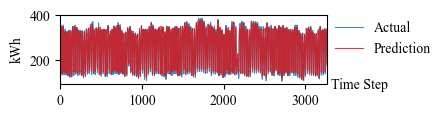

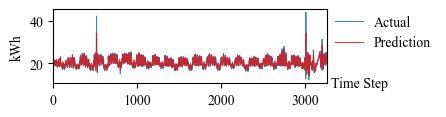

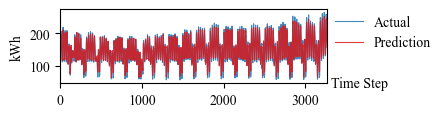

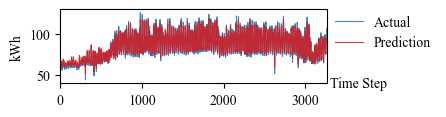

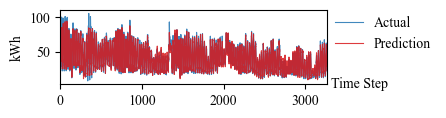

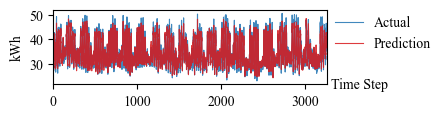

In [7]:
CURRENT_PLOT_DIR = TEMP_PLOT_DIR
os.makedirs(CURRENT_PLOT_DIR, exist_ok=True)
# ==========================================
# PLOT 1 – Actual vs Prediction (one figure per building, full series)
# ==========================================
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})
for bid in BUILDINGS:
    fig, ax = plt.subplots(figsize=(5, 1.7))
    df = results[bid]
    ax.plot(df['Actual'].values, color=COLORS['actual'], linewidth=0.8, label='Actual', alpha=0.9)
    ax.plot(df['Prediction'].values, color=COLORS['pred'], linewidth=0.8, label='Prediction', alpha=0.85)
    row = metrics_df[metrics_df['Building'] == bid].iloc[0]
    ax.set_ylabel('kWh', fontsize=10)
    ax.set_xlabel('Time Step', fontsize=10)
    ax.xaxis.set_label_coords(1.12, 0.1)
    ax.tick_params(labelsize=10)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10, frameon=False, borderaxespad=0)
    ax.margins(x=0)
    plt.tight_layout()
    save_path = os.path.join(CURRENT_PLOT_DIR, f'{bid}_actual_vs_predicted.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()


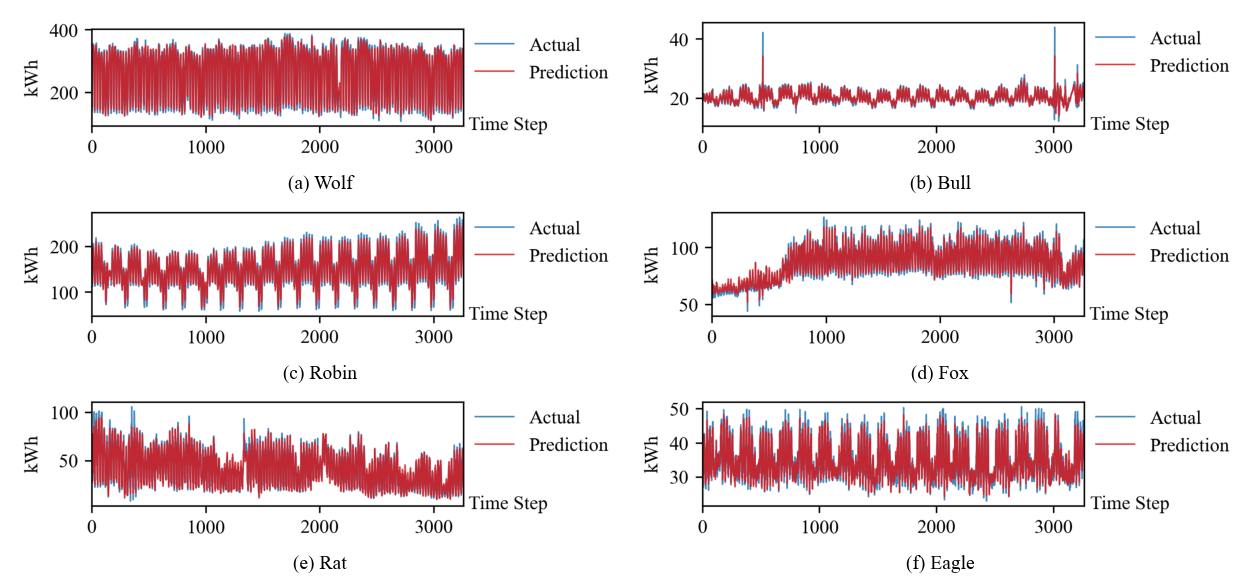

In [8]:
CURRENT_PLOT_DIR = TEMP_PLOT_DIR
os.makedirs(CURRENT_PLOT_DIR, exist_ok=True)
# ==========================================
# PLOT 1 – Combined grid (3×2) from saved images
# ==========================================
from PIL import Image

plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})

panel_labels = ['(a) Wolf', '(b) Bull', '(c) Robin', '(d) Fox', '(e) Rat', '(f) Eagle']

fig, axes = plt.subplots(3, 2, figsize=(16, 8))
axes_flat = axes.flatten()

for ax, bid, label in zip(axes_flat, BUILDINGS, panel_labels):
    img_path = os.path.join(TEMP_PLOT_DIR, f'{bid}_actual_vs_predicted.png')
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.text(0.5, -0.02, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=14)

plt.subplots_adjust(hspace=-0.2, wspace=0)
# save_path = os.path.join(TEMP_PLOT_DIR, 'combined_plot1_grid.png')
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()


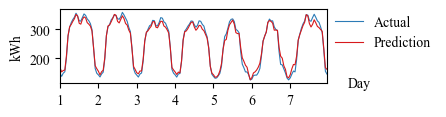

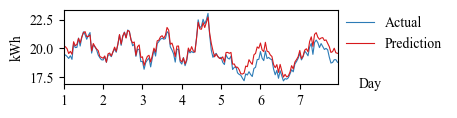

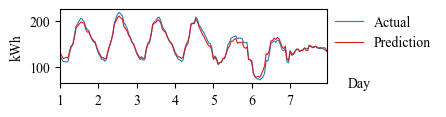

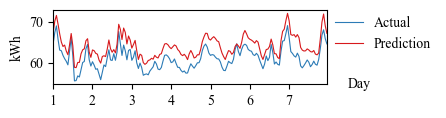

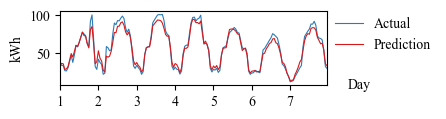

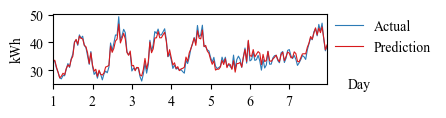

In [9]:
CURRENT_PLOT_DIR = TEMP_PLOT_DIR
os.makedirs(CURRENT_PLOT_DIR, exist_ok=True)
# ==========================================
# PLOT 2 – Zoomed view (first 7 days = 168 hours, one figure per building)
# ==========================================
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})
for bid in BUILDINGS:
    fig, ax = plt.subplots(figsize=(5, 1.7))
    df = results[bid].iloc[:ZOOM]
    ax.plot(df['Actual'].values, color=COLORS['actual'], linewidth=0.8, label='Actual')
    ax.plot(df['Prediction'].values, color=COLORS['pred'], linewidth=0.8, label='Prediction')
    ax.set_ylabel('kWh', fontsize=10)
    ax.set_xlabel('Day', fontsize=10)
    ax.set_xticks(range(0, ZOOM + 1, 24))
    ax.set_xticklabels([f'{i//24 + 1}' for i in range(0, ZOOM + 1, 24)], fontsize=10)
    ax.margins(x=0)
    ax.xaxis.set_label_coords(1.12, 0.1)
    ax.tick_params(labelsize=10)
    ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10, frameon=False, borderaxespad=0)
    plt.tight_layout()
    save_path = os.path.join(CURRENT_PLOT_DIR, f'{bid}_7days_zoom.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

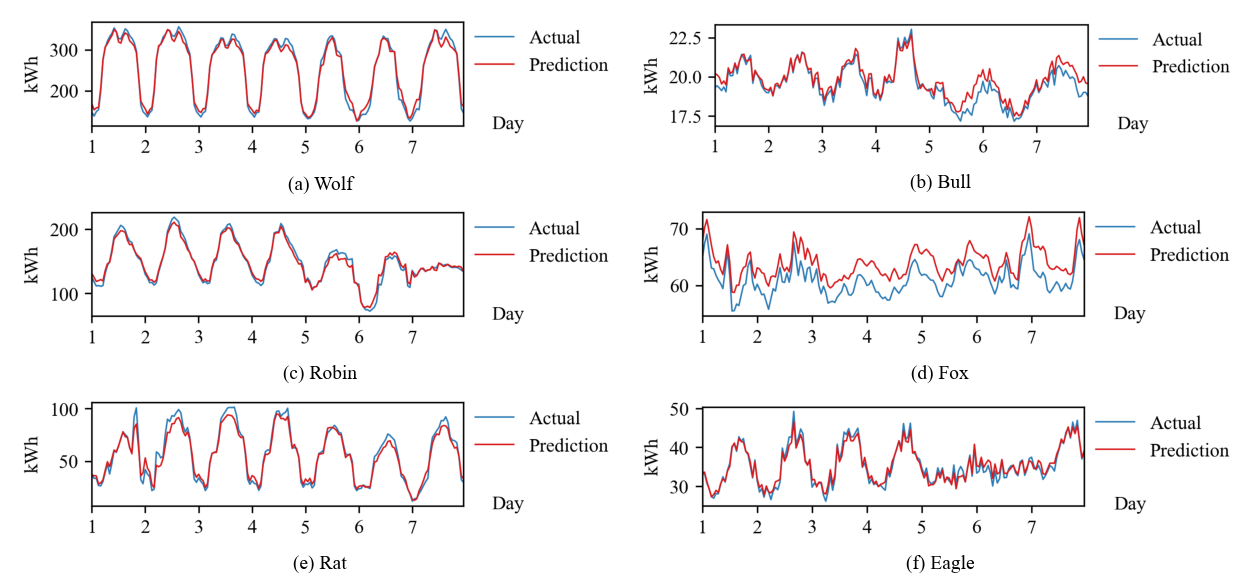

In [10]:
CURRENT_PLOT_DIR = TEMP_PLOT_DIR
os.makedirs(CURRENT_PLOT_DIR, exist_ok=True)
# ==========================================
# PLOT 2 – Zoomed view (first 7 days = 168 hours, one figure per building)
# ==========================================
from PIL import Image

plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})

panel_labels = ['(a) Wolf', '(b) Bull', '(c) Robin', '(d) Fox', '(e) Rat', '(f) Eagle']

fig, axes = plt.subplots(3, 2, figsize=(16, 8))
axes_flat = axes.flatten()

for ax, bid, label in zip(axes_flat, BUILDINGS, panel_labels):
    img_path = os.path.join(TEMP_PLOT_DIR, f'{bid}_7days_zoom.png')
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.text(0.5, -0.02, label, transform=ax.transAxes,
            ha='center', va='top', fontsize=14)

plt.subplots_adjust(hspace=-0.2, wspace=0)
# save_path = os.path.join(TEMP_PLOT_DIR, 'combined_plot2_grid.png')
# plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

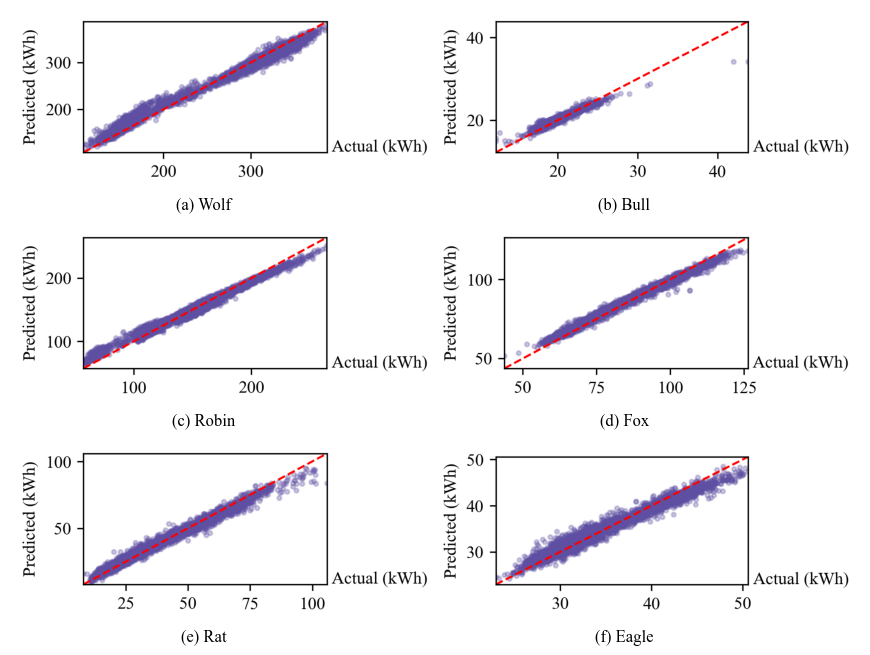

In [11]:
from PIL import Image

CURRENT_PLOT_DIR = TEMP_PLOT_DIR
os.makedirs(CURRENT_PLOT_DIR, exist_ok=True)
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})

# Individual scatter plots
for bid in BUILDINGS:
    fig, ax = plt.subplots(figsize=(4, 2))
    df = results[bid]
    ax.scatter(df['Actual'], df['Prediction'], alpha=0.3, s=6, color='#5e4fa2')
    mn = min(df['Actual'].min(), df['Prediction'].min())
    mx = max(df['Actual'].max(), df['Prediction'].max())
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=1.2)
    ax.set_ylabel('Predicted (kWh)', fontsize=10)
    ax.tick_params(labelsize=10)
    ax.margins(0)
    # Place xlabel outside axes with clip_on=False so bbox_inches='tight' captures it fully
    ax.text(1.02, 0.1, 'Actual (kWh)', transform=ax.transAxes,
            ha='left', va='top', fontsize=10, clip_on=False)
    plt.tight_layout()
    plt.savefig(os.path.join(CURRENT_PLOT_DIR, f'{bid}_scatter.png'), dpi=300, bbox_inches='tight')
    plt.close()

# Combined grid
panel_labels = ['(a) Wolf', '(b) Bull', '(c) Robin', '(d) Fox', '(e) Rat', '(f) Eagle']
fig, axes = plt.subplots(3, 2, figsize=(19, 8))
for ax, bid, label in zip(axes.flatten(), BUILDINGS, panel_labels):
    ax.imshow(Image.open(os.path.join(CURRENT_PLOT_DIR, f'{bid}_scatter.png')))
    ax.axis('off')
    ax.text(0.45, -0.02, label, transform=ax.transAxes, ha='center', va='top', fontsize=12)

plt.subplots_adjust(hspace=0.18, wspace=-0.6)
# plt.savefig(os.path.join(CURRENT_PLOT_DIR, 'combined_plot3_grid.png'), dpi=300, bbox_inches='tight')
plt.show()
plt.close()

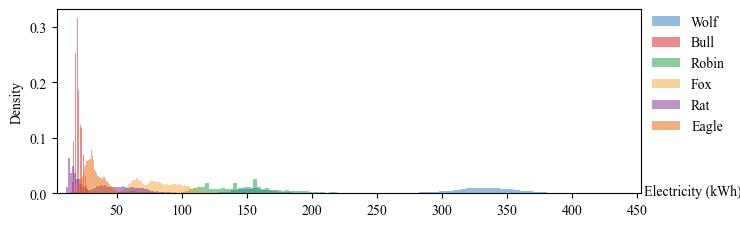

In [12]:
CURRENT_PLOT_DIR = TEMP_PLOT_DIR
os.makedirs(CURRENT_PLOT_DIR, exist_ok=True)
# Raw data distribution per building (all in one figure)
plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})
df_elec = pd.read_csv(ELEC_PATH)

building_colors = {
    'Wolf':  '#2c7bb6',
    'Bull':  '#d7191c',
    'Robin': '#1a9641',
    'Fox':   '#f4a742',
    'Rat':   '#7b2d8b',
    'Eagle': '#e66101',
}

fig, ax = plt.subplots(figsize=(8, 2.8))
for bid in BUILDINGS:
    col = next((c for c in df_elec.columns if c.startswith(bid + '_')), None)
    if col is None:
        continue
    values = df_elec[col].interpolate(method='linear').ffill().bfill().values
    ax.hist(values, bins=80, alpha=0.5, color=building_colors[bid],
            label=bid, density=True, edgecolor='none')

ax.set_xlabel('Electricity (kWh)', fontsize=10)
ax.set_ylabel('Density', fontsize=10)
ax.xaxis.set_label_coords(1.088, 0.05)
ax.tick_params(labelsize=10)
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=10, frameon=False, borderaxespad=0)
ax.margins(x=0)
plt.tight_layout()
# save_path = os.path.join(TEMP_PLOT_DIR, 'combined_plot3_grid.png')
# plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.11)
plt.show()
plt.close()

Loading: c:\Users\DESKTOP\Desktop\electricity forecasting\archive\ready_to_run\v2\meters\cleaned\electricity_cleaned.csv
Running VMD (K=6) on 48 samples...
VMD complete — 6 modes extracted.


C:\Users\DESKTOP\AppData\Local\Temp\ipykernel_15560\3781335927.py:44: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = (series
C:\Users\DESKTOP\AppData\Local\Temp\ipykernel_15560\3781335927.py:71: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  series = pd.Series(series).interpolate(method='linear').fillna(method='bfill').values


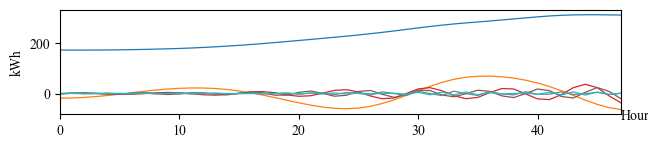

In [13]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from vmdpy import VMD

# ==========================================
# CONFIGURATION
# ==========================================
try:
    BASE_DIR = os.path.dirname(os.path.abspath(__file__))
except NameError:
    BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "meters", "cleaned")
OUTPUT_DIR = os.path.join(BASE_DIR, "results_all_experiments")
PLOT_DIR = os.path.join(OUTPUT_DIR, "plots_for_paper")

CONFIG = {
    'electricity_path': os.path.join(DATA_DIR, "electricity_cleaned.csv"),
    'sample_building': 'Wolf',
    'start_time': '2016-01-01 00:00:00',
    'end_time':   '2016-01-02 23:00:00',
    'save_dir': PLOT_DIR,
    'vmd': {
        'alpha': 2000,
        'tau':   0,
        'K':     6,
        'DC':    0,
        'init':  1,
        'tol':   1e-7,
    },
}

# Ensure save directory exists when running inside the notebook.
os.makedirs(CONFIG['save_dir'], exist_ok=True)

# ==========================================
# HELPERS
# ==========================================
def clean_flat_sequences(series, window_size=5, threshold=1e-5):
    series = pd.Series(series)
    rolling_std = series.rolling(window=window_size).std()
    series[rolling_std < threshold] = np.nan
    series = (series
              .interpolate(method='linear')
              .fillna(method='bfill')
              .fillna(method='ffill'))
    return series.values

# ==========================================
# MAIN
# ==========================================
def main():
    # 1. Load & preprocess
    print(f"Loading: {CONFIG['electricity_path']}")
    df = pd.read_csv(CONFIG['electricity_path'])

    bid = CONFIG['sample_building']
    col = next((c for c in df.columns if bid in c), None)
    if col is None:
        raise ValueError(f"Building '{bid}' not found in columns: {df.columns.tolist()}")

    df['timestamp'] = pd.to_datetime(df['timestamp'])
    mask = (df['timestamp'] >= CONFIG['start_time']) & (df['timestamp'] <= CONFIG['end_time'])
    df_filtered = df.loc[mask]
    if df_filtered.empty:
        raise ValueError(f"No data in range {CONFIG['start_time']} → {CONFIG['end_time']}")

    raw = df_filtered[col].values
    series = clean_flat_sequences(raw)
    series = pd.Series(series).interpolate(method='linear').fillna(method='bfill').values

    signal    = series
    time_axis = np.arange(len(signal))

    # 2. Run VMD
    vp = CONFIG['vmd']
    print(f"Running VMD (K={vp['K']}) on {len(signal)} samples...")
    u, u_hat, omega = VMD(signal,
                          vp['alpha'], vp['tau'], vp['K'],
                          vp['DC'],    vp['init'], vp['tol'])
    K = u.shape[0]
    print(f"VMD complete — {K} modes extracted.")

    # 3. Plot overlay (Figure 3)
    plt.rcParams.update({'font.family': 'serif', 'font.serif': ['Times New Roman']})

    colors = plt.cm.tab10(np.linspace(0, 0.9, K))

    fig, ax = plt.subplots(figsize=(7, 2))

    for i in range(K):
        ax.plot(time_axis, u[i], color=colors[i], linewidth=0.9, label=f'IMF {i+1}')

    ax.set_xlabel('Hours', fontsize=10)
    ax.set_ylabel('kWh',   fontsize=10)
    ax.set_xlim(time_axis[0], time_axis[-1])
    ax.tick_params(labelsize=10)
    ax.xaxis.set_label_coords(1.03, 0.05)

    plt.tight_layout()
    # save_path = os.path.join(CONFIG['save_dir'], f"{bid}_vmd_modes_overlay.png")
    # plt.savefig(save_path, dpi=300, bbox_inches='tight')
    # print(f"Saved: {save_path}")

    plt.show()

# Run directly in the notebook cell.
main()

plt.close()

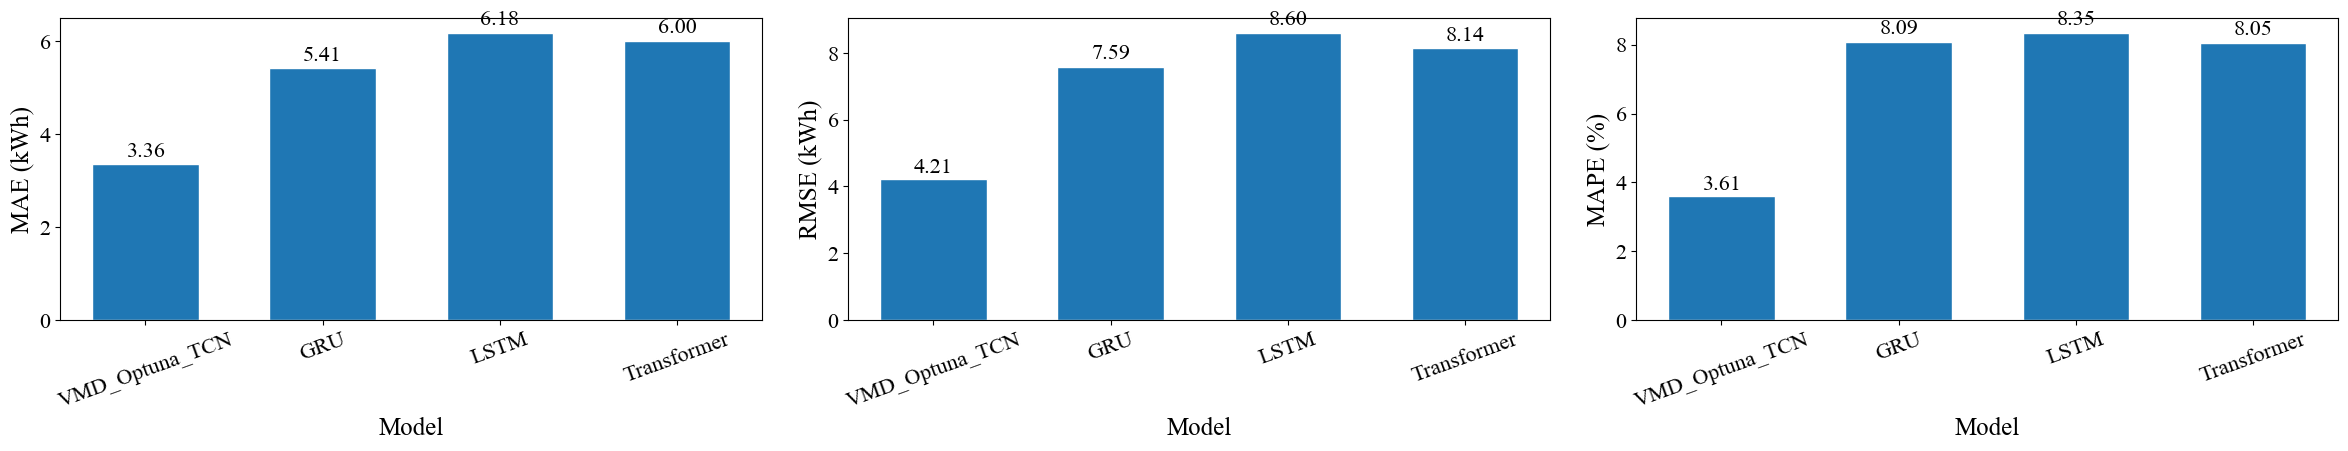

,Model,MAE,RMSE,MAPE
0,VMD_Optuna_TCN,3.360325,4.211497,3.611315
1,GRU,5.408821,7.586190,8.087667
2,LSTM,6.175099,8.604931,8.349230
3,Transformer,5.996045,8.142192,8.048155


In [14]:
import os
import matplotlib.pyplot as plt
import pandas as pd


def plot_model_metrics_comparison(metrics_all_df, dataset_name='test', plot_dir=PLOT_DIR,
                                  buildings=BUILDINGS, font_size=18,
                                  filename='all_models_metrics_comparison.png'):
    """
    Plot MAE, RMSE, and MAPE for all models using the single output file:
    results_all_experiments/metrics/all_metrics.csv
    """
    model_order = ['VMD_Optuna_TCN', 'GRU', 'LSTM', 'Transformer']
    metric_cfg = [
        ('MAE',  'MAE (kWh)'),
        ('RMSE', 'RMSE (kWh)'),
        ('MAPE', 'MAPE (%)'),
    ]

    df = metrics_all_df[
        (metrics_all_df['Dataset'] == dataset_name) &
        (metrics_all_df['Building'].isin(buildings)) &
        (metrics_all_df['Model'].isin(model_order))
    ].copy()

    # Mean across buildings for each model.
    summary = (
        df.groupby('Model')[['MAE', 'RMSE', 'MAPE']]
        .mean()
        .reindex(model_order)
        .reset_index()
    )

    os.makedirs(plot_dir, exist_ok=True)
    fig, axes = plt.subplots(1, 3, figsize=(24, 5))

    for ax, (col, ylabel) in zip(axes, metric_cfg):
        bars = ax.bar(summary['Model'], summary[col], edgecolor='white', width=0.6)
        ax.set_ylabel(ylabel, fontsize=font_size)
        ax.set_xlabel('Model', fontsize=font_size)
        ax.tick_params(axis='x', labelrotation=20, labelsize=font_size - 2)
        ax.tick_params(axis='y', labelsize=font_size - 2)

        for bar, val in zip(bars, summary[col]):
            if pd.notna(val):
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.01,
                    f'{val:.2f}',
                    ha='center', va='bottom',
                    fontsize=font_size - 2,
                )

    plt.tight_layout()
    plt.show()
    return summary


metrics_all_df = pd.read_csv(os.path.join(METRICS_DIR, 'all_metrics.csv'))
model_summary_df = plot_model_metrics_comparison(
    metrics_all_df,
    dataset_name='test',
    plot_dir=PLOT_DIR,
    buildings=BUILDINGS,
    filename='all_models_test_metrics_comparison.png'
)
model_summary_df
